## Semana 4 Día 4 - ¡preparando el gran proyecto!

# El Sidekick

Es hora de introducir:

1. Salidas estructuradas
2. Un flujo multi-agente

In [1]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv

In [2]:
load_dotenv(override=True)

True

### Para salidas estructuradas, definimos un objeto Pydantic para el Esquema

In [ ]:
# Define el esquema de salida para el evaluador

class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Comentarios sobre la respuesta del asistente")
    success_criteria_met: bool = Field(description="Si los criterios de éxito han sido cumplidos")
    user_input_needed: bool = Field(description="True si se necesita más información del usuario, o aclaraciones, o el asistente está atascado")


### Y para el Estado, usaremos TypedDict de nuevo

¡Pero ahora tenemos información real para mantener!

Los mensajes usan el reductor. Los demás son simplemente valores que sobrescribimos con cualquier cambio de estado.

In [ ]:
# Define el estado del grafo

class State(TypedDict):
    messages: Annotated[List[Any], add_messages] # Lista de mensajes en el estado actual
    success_criteria: str # Criterios de éxito para la tarea
    feedback_on_work: Optional[str] # Feedback sobre el trabajo realizado hasta ahora
    success_criteria_met: bool # Si se han cumplido los criterios de éxito
    user_input_needed: bool # Si se necesita más información del usuario

In [ ]:
# Descarga nuestras herramientas asíncronas de Playwright
# Si te aparece un NotImplementedError aquí o más adelante, consulta la nota de advertencia que aparece al principio del cuaderno 3_lab3


import nest_asyncio
nest_asyncio.apply()
async_browser =  create_async_playwright_browser(headless=False)  # modo con cabeza
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [ ]:
# Inicializar los LLMs

worker_llm = ChatOpenAI(model="gpt-4o-mini")
worker_llm_with_tools = worker_llm.bind_tools(tools) # El trabajador ahora tiene acceso a las herramientas de Playwright

evaluator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluator_llm_with_output = evaluator_llm.with_structured_output(EvaluatorOutput) # El evaluador devuelve salida estructurada

In [10]:
# The worker node

def worker(state: State) -> Dict[str, Any]:
    # El trabajador es un asistente que puede usar herramientas para completar tareas
    # Continúa trabajando en una tarea hasta que tenga una pregunta o aclaración para el usuario,
    # o hasta que se cumplan los criterios de éxito
    system_message = f"""Eres un asistente útil que puede usar herramientas para completar tareas.
Continúas trabajando en una tarea hasta que tengas una pregunta o aclaración para el usuario, o hasta que se cumplan los criterios de éxito.
Estos son los criterios de éxito:
{state['success_criteria']}
Debes responder ya sea con una pregunta para el usuario sobre esta tarea, o con tu respuesta final.
Si tienes una pregunta para el usuario, necesitas responder indicando claramente tu pregunta. Un ejemplo podría ser:

Pregunta: por favor clarifica si quieres un resumen o una respuesta detallada

Si has terminado, responde con la respuesta final, y no hagas una pregunta; simplemente responde con la respuesta.
"""
    
    if state.get("feedback_on_work"):
        system_message += f"""
Anteriormente pensaste que completaste la tarea, pero tu respuesta fue rechazada porque no se cumplieron los criterios de éxito.
Aquí está el feedback de por qué fue rechazada:
{state['feedback_on_work']}
Con este feedback, por favor continúa con la tarea, asegurándote de cumplir los criterios de éxito o tener una pregunta para el usuario."""
    
    # Agregar el mensaje del sistema

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True
    
    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages
    
    # Invocar el LLM con herramientas
    response = worker_llm_with_tools.invoke(messages)
    
    # Retornar el estado actualizado
    return {
        "messages": [response],
    }

In [11]:
def worker_router(state: State) -> str:
    # Decide si el trabajador necesita usar herramientas o pasar al evaluador
    last_message = state["messages"][-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    else:
        return "evaluator"

In [12]:
def format_conversation(messages: List[Any]) -> str:
    # Formatea la conversación para mostrar el historial
    conversation = "Historial de conversación:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"Usuario: {message.content}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Uso de herramientas]"
            conversation += f"Asistente: {text}\n"
    return conversation

In [13]:
def evaluator(state: State) -> State:
    # El evaluador determina si una tarea ha sido completada exitosamente por un Asistente
    last_response = state["messages"][-1].content

    system_message = """Eres un evaluador que determina si una tarea ha sido completada exitosamente por un Asistente.
Evalúa la última respuesta del Asistente basándote en los criterios dados. Responde con tu feedback, y con tu decisión sobre si los criterios de éxito han sido cumplidos,
y si se necesita más información del usuario."""
    
    user_message = f"""Estás evaluando una conversación entre el Usuario y el Asistente. Decides qué acción tomar basándote en la última respuesta del Asistente.

Toda la conversación con el asistente, con la solicitud original del usuario y todas las respuestas, es:
{format_conversation(state['messages'])}

Los criterios de éxito para esta tarea son:
{state['success_criteria']}

Y la respuesta final del Asistente que estás evaluando es:
{last_response}

Responde con tu feedback, y decide si los criterios de éxito se cumplen con esta respuesta.
También decide si se requiere más información del usuario, ya sea porque el asistente tiene una pregunta, necesita clarificación, o parece estar atascado y no puede responder sin ayuda.
"""
    if state["feedback_on_work"]:
        user_message += f"También, ten en cuenta que en un intento previo del Asistente, proporcionaste este feedback: {state['feedback_on_work']}\n"
        user_message += "Si ves al Asistente cometiendo los mismos errores, entonces considera responder que se requiere información del usuario."
    
    evaluator_messages = [SystemMessage(content=system_message), HumanMessage(content=user_message)]

    eval_result = evaluator_llm_with_output.invoke(evaluator_messages)
    new_state = {
        "messages": [{"role": "assistant", "content": f"Feedback del Evaluador sobre esta respuesta: {eval_result.feedback}"}],
        "feedback_on_work": eval_result.feedback,
        "success_criteria_met": eval_result.success_criteria_met,
        "user_input_needed": eval_result.user_input_needed
    }
    return new_state

In [14]:
def route_based_on_evaluation(state: State) -> str:
    # Decide si continuar trabajando o terminar basado en la evaluación
    if state["success_criteria_met"] or state["user_input_needed"]:
        return "END"
    else:
        return "worker"

In [15]:
# Configurar el Constructor del Grafo con Estado
graph_builder = StateGraph(State)

# Agregar nodos
graph_builder.add_node("worker", worker)
graph_builder.add_node("tools", ToolNode(tools=tools))
graph_builder.add_node("evaluator", evaluator)

# Agregar aristas
graph_builder.add_conditional_edges("worker", worker_router, {"tools": "tools", "evaluator": "evaluator"})
graph_builder.add_edge("tools", "worker")
graph_builder.add_conditional_edges("evaluator", route_based_on_evaluation, {"worker": "worker", "END": END})
graph_builder.add_edge(START, "worker")

# Compilar el grafo
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

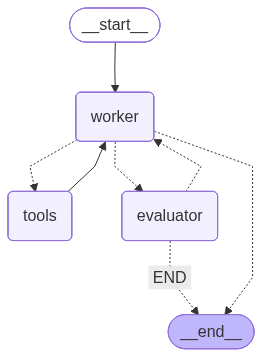

In [16]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Límites en LangGraph (Recursión)

Si estás usando LangGraph, hay un límite específico para evitar bucles infinitos llamado `recursion_limit`. Este se cambia al momento de ejecutar el grafo:

```python
app.invoke(inputs, config={"recursion_limit": 50})  # El valor por defecto suele ser 25
```

Usa el código con precaución.

### A continuación viene el Callback de gradio para iniciar un super-paso

In [23]:
def make_thread_id() -> str:
    return str(uuid.uuid4())


async def process_message(message, success_criteria, history, thread):
    # Procesa el mensaje del usuario a través del grafo de LangGraph
    # Aumentamos el recursion_limit para evitar errores por límite de recursión
    config = {"configurable": {"thread_id": thread}, "recursion_limit": 50}

    state = {
        "messages": message,
        "success_criteria": success_criteria,
        "feedback_on_work": None,
        "success_criteria_met": False,
        "user_input_needed": False
    }
    result = await graph.ainvoke(state, config=config)
    user = {"role": "user", "content": message}
    reply = {"role": "assistant", "content": result["messages"][-2].content}
    feedback = {"role": "assistant", "content": result["messages"][-1].content}
    return history + [user, reply, feedback]

async def reset():
    # Reinicia el chat y crea un nuevo thread ID
    return "", "", None, make_thread_id()



### Y ahora lanzamos nuestra UI de Sidekick

In [25]:

with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## Sidekick Co-trabajador Personal")
    thread = gr.State(make_thread_id())
    
    with gr.Row():
        chatbot = gr.Chatbot(label="Sidekick", height=300, type="messages")
    with gr.Group():
        with gr.Row():
            message = gr.Textbox(show_label=False, placeholder="Tu solicitud para tu sidekick")
        with gr.Row():
            success_criteria = gr.Textbox(show_label=False, placeholder="¿Cuáles son tus criterios de éxito?")
    with gr.Row():
        reset_button = gr.Button("Reiniciar", variant="stop")
        go_button = gr.Button("¡Ir!", variant="primary")
    message.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    success_criteria.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    go_button.click(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    reset_button.click(reset, [], [message, success_criteria, chatbot, thread])

    
demo.launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thanks.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00cc00;">Congratulations on making the first version of Sidekick!</h2>
            <span style="color:#00cc00;">This is a pretty epic moment in the course. You've made the start of something very powerful. And you've upskilled on an impressive Agent framework in LangGraph. Maybe like me you're being converted from a LangGraph skeptic to a LangGraph fan..<br/><br/>My editor would kill me if I didn't mention again: if you're able to rate the course on Udemy, I'd be so very grateful: it's the main way that Udemy decides whether to show the course to others and it makes a massive difference.<br/><br/>And another reminder that I love <a href="https://www.linkedin.com/in/eddonner/">connecting on LinkedIn</a> if you haven't yet! If you wanted to post about your progress on the course, please tag me and I'll weigh in to increase your exposure.
            </span>
        </td>
    </tr>